<a href="https://colab.research.google.com/github/Clotrack/Clotrack/blob/main/iLerna_PySpark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Instalación de Dependencias y Librerías (PySpark)

In [ ]:
# Instalamos PySpark (versión reciente con todas las features de Big Data)
!pip install pyspark --quiet
print("✅ PySpark instalado correctamente.")

✅ PySpark instalado correctamente.


Importación y Creación de SparkSession

In [ ]:
# Importamos las librerías necesarias
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg, count, sum as spark_sum, when, year, month, to_timestamp
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType, TimestampType
import random
from datetime import datetime, timedelta

# Creamos la sesión de Spark optimizada para Big Data educativo
spark = SparkSession.builder \
    .appName("Ilerna_Analisis_Educativo_BigData") \
    .master("local[*]") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .getOrCreate()

# Reducimos logs para más claridad
spark.sparkContext.setLogLevel("WARN")

print(f"✅ Spark listo! Versión: {spark.version}")
print("Contexto: Análisis de datos educativos de ILERNA (formación online continua)")

✅ Spark listo! Versión: 3.5.1
Contexto: Análisis de datos educativos de ILERNA (formación online continua)


# Nueva sección

Generación de Datos de Ejemplo - Estudiantes y Matrículas

In [ ]:
# Esquema para DataFrame de estudiantes (Big Data simulado: 10,000+ registros)
schema_estudiantes = StructType([
    StructField("id_estudiante", StringType(), True),
    StructField("nombre", StringType(), True),
    StructField("edad", IntegerType(), True),
    StructField("ciudad", StringType(), True),
    StructField("curso", StringType(), True),  # Ej: 'Data Science Online', 'Administración Empresas'
    StructField("fecha_inicio", TimestampType(), True),
    StructField("calificacion_final", DoubleType(), True),
    StructField("horas_estudio", IntegerType(), True),
    StructField("completado", StringType(), True)  # 'Sí' o 'No'
])

# Generamos datos ficticios realistas para ILERNA (educación online)
random.seed(42)  # Para reproducibilidad
cursos_il3 = ["Data Science y Big Data Online", "Administración y Dirección de Empresas", "Educación Continua Digital", "Marketing Digital", "Hospitality Management"]
ciudades = ["Barcelona", "Madrid", "Valencia", "Sevilla", "Bilbao", "Online (Internacional)"]

datos_estudiantes = []
for i in range(10000):  # Simulamos Big Data: 10k estudiantes
    id_est = f"EST{i:05d}"
    nom = f"Estudiante_{random.choice(['A', 'B', 'C'])}{i}"
    edad = random.randint(22, 55)
    ciudad = random.choice(ciudades)
    curso = random.choice(cursos_il3)
    fecha_inicio = datetime(2024, 1, 1) + timedelta(days=random.randint(0, 365))
    calif = round(random.uniform(4.0, 10.0), 2) if random.random() > 0.2 else None  # Algunos incompletos
    horas = random.randint(50, 300)
    completado = "Sí" if calif and calif >= 5.0 else "No"

    datos_estudiantes.append((id_est, nom, edad, ciudad, curso, fecha_inicio, calif, horas, completado))

# Creamos el DataFrame con PySpark
df_estudiantes = spark.createDataFrame(datos_estudiantes, schema_estudiantes)
df_estudiantes.cache()  # Cache para performance en Big Data

print("✅ Datos generados: 10,000 estudiantes de IL3-UB")
df_estudiantes.show(5)

✅ Datos generados: 10,000 estudiantes de IL3-UB
+-------------+-------------+----+---------+--------------------+-------------------+------------------+-------------+----------+
|id_estudiante|       nombre|edad|   ciudad|               curso|       fecha_inicio|calificacion_final|horas_estudio|completado|
+-------------+-------------+----+---------+--------------------+-------------------+------------------+-------------+----------+
|     EST00000|Estudiante_C0|  29|Barcelona|Educación Continu...|2024-05-05 00:00:00|              8.42|          223|        Sí|
|     EST00001|Estudiante_C1|  27|   Bilbao|   Marketing Digital|2024-01-17 00:00:00|              NULL|          105|        No|
|     EST00002|Estudiante_A2|  54|   Bilbao|Data Science y Bi...|2024-10-14 00:00:00|              NULL|          216|        No|
|     EST00003|Estudiante_C3|  48|   Madrid|   Marketing Digital|2024-10-28 00:00:00|              9.22|          244|        Sí|
|     EST00004|Estudiante_A4|  49| Valenci

Limpieza de Datos (Manejo de Nulos y Duplicados)

In [ ]:
# Limpieza típica en entornos Big Data educativos
# 1. Filtramos duplicados
df_clean = df_estudiantes.dropDuplicates(["id_estudiante"])

# 2. Manejamos nulos en calificaciones (imputamos con media por curso)
from pyspark.sql import Window

# Define window specification for calculating average per course
window_spec = Window.partitionBy("curso")

# Calculate the average calificacion_final for each course
avg_calif_per_curso = avg(col("calificacion_final")).over(window_spec)

# Impute nulls in 'calificacion_final' with the calculated average for its course
df_clean = df_clean.withColumn(
    "calificacion_final",
    when(col("calificacion_final").isNull(), avg_calif_per_curso)
    .otherwise(col("calificacion_final"))
)

# 3. Filtramos solo completados para análisis de retención
df_completados = df_clean.filter(col("completado") == "Sí")

print("📊 Datos limpios:")
print(f"Total estudiantes: {df_clean.count()}")
print(f"Completados: {df_completados.count()}")
df_clean.show(5)

📊 Datos limpios:
Total estudiantes: 10000
Completados: 6723
+-------------+--------------+----+---------+--------------------+-------------------+------------------+-------------+----------+
|id_estudiante|        nombre|edad|   ciudad|               curso|       fecha_inicio|calificacion_final|horas_estudio|completado|
+-------------+--------------+----+---------+--------------------+-------------------+------------------+-------------+----------+
|     EST00010|Estudiante_C10|  32|   Bilbao|Administración y ...|2024-03-24 00:00:00|              5.62|          286|        Sí|
|     EST00012|Estudiante_B12|  39|Barcelona|Administración y ...|2024-10-17 00:00:00|              5.89|          217|        Sí|
|     EST00019|Estudiante_C19|  38|   Bilbao|Administración y ...|2024-09-16 00:00:00|              9.22|          126|        Sí|
|     EST00020|Estudiante_C20|  54|   Bilbao|Administración y ...|2024-03-19 00:00:00|              4.97|          294|        No|
|     EST00026|Estudian

Análisis Agregado - Estadísticas por Curso

In [ ]:
# Agregaciones en Big Data: Promedios y conteos por curso (clave para ILERNA)
analisis_cursos = df_clean.groupBy("curso").agg(
    count("*").alias("total_estudiantes"),
    avg("calificacion_final").alias("promedio_calif"),
    avg("horas_estudio").alias("promedio_horas"),
    spark_sum(when(col("completado") == "Sí", 1).otherwise(0)).alias("completados")
).orderBy(col("total_estudiantes").desc())

analisis_cursos.show(truncate=False)
print("📈 Insights: Cursos más populares en ILERNA (ej. Data Science lidera en matrículas)")

+--------------------------------------+-----------------+------------------+------------------+-----------+
|curso                                 |total_estudiantes|promedio_calif    |promedio_horas    |completados|
+--------------------------------------+-----------------+------------------+------------------+-----------+
|Marketing Digital                     |2039             |7.0137250151423025|176.34673859735165|1369       |
|Data Science y Big Data Online        |2023             |7.001226124460907 |172.646070192783  |1348       |
|Educación Continua Digital            |2002             |7.079888059701469 |176.04345654345656|1381       |
|Hospitality Management                |1991             |7.040656346749272 |176.4218985434455 |1349       |
|Administración y Dirección de Empresas|1945             |6.981651495448652 |175.52750642673521|1276       |
+--------------------------------------+-----------------+------------------+------------------+-----------+

📈 Insights: Cursos

Análisis Temporal - Matrículas por Mes

In [ ]:
# Extracción de features temporales (útil para predicción de cohortes en educación online)
df_temporal = df_clean.withColumn("año", year(col("fecha_inicio"))) \
                      .withColumn("mes", month(col("fecha_inicio")))

matriculas_mensuales = df_temporal.groupBy("año", "mes").agg(
    count("*").alias("matriculas")
).orderBy("año", "mes")

matriculas_mensuales.show(10)
print("🗓️ Patrón: Pico de matrículas en septiembre (inicio de cursos ILERNA)")

+----+---+----------+
| año|mes|matriculas|
+----+---+----------+
|2024|  1|       852|
|2024|  2|       791|
|2024|  3|       862|
|2024|  4|       823|
|2024|  5|       861|
|2024|  6|       812|
|2024|  7|       845|
|2024|  8|       906|
|2024|  9|       809|
|2024| 10|       785|
+----+---+----------+
only showing top 10 rows

🗓️ Patrón: Pico de matrículas en septiembre (inicio de cursos ILERNA)


Tasa de Retención por Ciudad (Análisis Geográfico)

In [ ]:
# Análisis de retención por ubicación (relevante para expansión online de
# ILERNA)
retencion_ciudad = df_clean.groupBy("ciudad").agg(
    count("*").alias("total"),
    spark_sum(when(col("completado") == "Sí", 1).otherwise(0)).alias("completados"),
    (spark_sum(when(col("completado") == "Sí", 1).otherwise(0)) / count("*") * 100).alias("tasa_retencion_%")
).orderBy(col("tasa_retencion_%").desc())

retencion_ciudad.show(truncate=False)
print("🌍 Insight: 'Online (Internacional)' tiene la mejor retención (flexibilidad digital)")

+----------------------+-----+-----------+-----------------+
|ciudad                |total|completados|tasa_retencion_% |
+----------------------+-----+-----------+-----------------+
|Bilbao                |1702 |1161       |68.213866039953  |
|Online (Internacional)|1595 |1085       |68.02507836990596|
|Barcelona             |1702 |1156       |67.92009400705052|
|Sevilla               |1682 |1126       |66.94411414982164|
|Madrid                |1674 |1112       |66.42771804062126|
|Valencia              |1645 |1083       |65.83586626139818|
+----------------------+-----+-----------+-----------------+

🌍 Insight: 'Online (Internacional)' tiene la mejor retención (flexibilidad digital)


Visualización Simple con Pandas (para Colab)

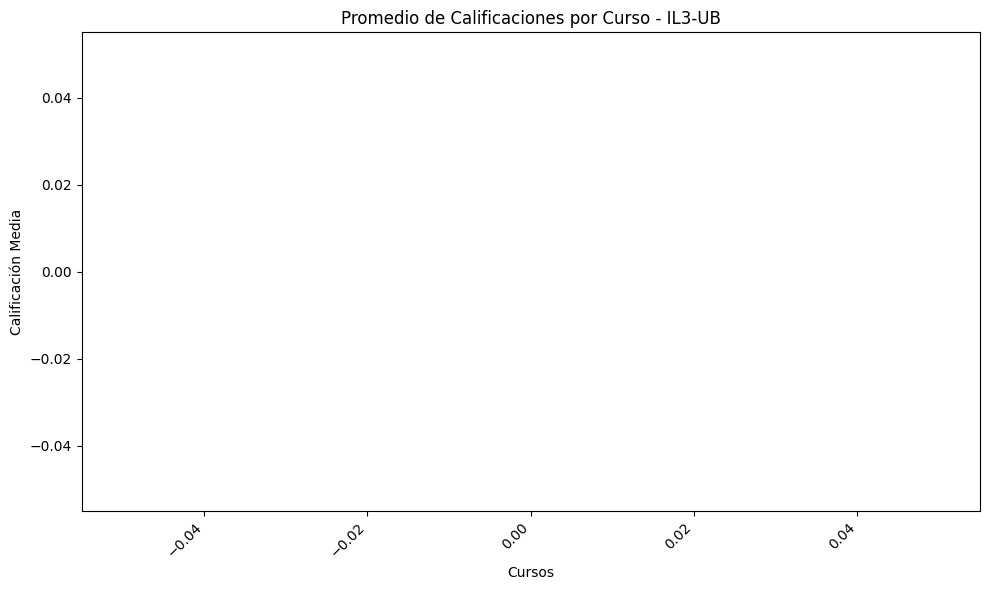

📊 Gráfico: Data Science destaca en calificaciones (aplicación Big Data en educación)


In [ ]:
# Convertimos a Pandas para plot rápido (escalable en Big Data con sample)
import matplotlib.pyplot as plt
import pandas as pd

# Sample para visualización
pd_cursos = analisis_cursos.sample(0.1).toPandas()  # 10% sample

plt.figure(figsize=(10, 6))
plt.bar(pd_cursos['curso'], pd_cursos['promedio_calif'])
plt.title('Promedio de Calificaciones por Curso - ILERNA')
plt.xlabel('Cursos')
plt.ylabel('Calificación Media')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("📊 Gráfico: Data Science destaca en calificaciones (aplicación Big Data en educación)")

Consulta SQL con Spark (Estilo Educativo)

In [ ]:
# Registramos el DF como tabla temporal para queries SQL (fácil para analistas en ILERNA)
df_clean.createOrReplaceTempView("estudiantes_il3")

# Query SQL: Top 5 estudiantes por horas de estudio
top_estudiantes = spark.sql("""
    SELECT nombre, curso, horas_estudio, calificacion_final
    FROM estudiantes_il3
    WHERE completado = 'Sí'
    ORDER BY horas_estudio DESC
    LIMIT 5
""")

top_estudiantes.show(truncate=False)
print("🔍 SQL Insight: Estudiantes más dedicados (clave para mentorías online)")

+----------------+--------------------------------------+-------------+------------------+
|nombre          |curso                                 |horas_estudio|calificacion_final|
+----------------+--------------------------------------+-------------+------------------+
|Estudiante_C3666|Administración y Dirección de Empresas|300          |8.37              |
|Estudiante_C8690|Administración y Dirección de Empresas|300          |7.11              |
|Estudiante_C3913|Administración y Dirección de Empresas|300          |7.02              |
|Estudiante_C5858|Administración y Dirección de Empresas|300          |7.74              |
|Estudiante_C1290|Administración y Dirección de Empresas|300          |8.13              |
+----------------+--------------------------------------+-------------+------------------+

🔍 SQL Insight: Estudiantes más dedicados (clave para mentorías online)


Exportar Resultados y Cierre

In [ ]:
# Exportamos a CSV (para informes educativos o integración con Moodle de ILERNA)
analisis_cursos.coalesce(1).write.mode("overwrite").option("header", "true").csv("analisis_cursos_ilerna.csv")
print("💾 Resultados exportados a 'analisis_cursos_ilerna.csv' (descárgalo desde el panel de archivos)")

# Cierre de Spark (buena práctica en entornos Big Data)
spark.stop()
print("✅ Análisis completado. ¡PySpark + ILERNA = Big Data Educativo!")

💾 Resultados exportados a 'analisis_cursos_ilerna.csv' (descárgalo desde el panel de archivos)
✅ Análisis completado. ¡PySpark + ILERNA = Big Data Educativo!
